# 02. Train MLP

전처리 결과를 사용해 `MLP`를 학습하고 성능을 저장합니다.

In [1]:

%matplotlib inline

import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
except ImportError as error:
    raise ImportError('tensorflow가 설치되어 있지 않습니다.') from error

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str((OUTPUT_DIR / '.mplconfig').resolve()))
(OUTPUT_DIR / '.mplconfig').mkdir(parents=True, exist_ok=True)

RUN_SEEDS = [42]
MLP_EPOCHS = 30
BATCH_SIZE = 256
LEARNING_RATE = 0.001
PERMUTATION_REPEATS = 3


In [2]:
def print_section(title: str) -> None:
    # 구간 출력
    line = '=' * 50
    print('\n' + line)
    print(title)
    print(line)


def set_seed(seed: int) -> None:
    # 시드 고정
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # 성능 계산
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.int32)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }


def load_data() -> dict:
    # 데이터 로드
    print_section('[INFO] MLP 데이터 로드')
    sample_path = OUTPUT_DIR / 'samples.csv'
    if not sample_path.exists():
        raise FileNotFoundError('먼저 01_prepare_data.ipynb를 실행하세요.')
    samples = pd.read_csv(sample_path)
    feature_columns = [column for column in samples.columns if column.startswith('hist_')]
    train_frame = samples.loc[samples['split'] == 'train'].copy()
    val_frame = samples.loc[samples['split'] == 'val'].copy()
    test_frame = samples.loc[samples['split'] == 'test'].copy()

    scaler = StandardScaler()
    x_train = scaler.fit_transform(train_frame[feature_columns].to_numpy(dtype=np.float32))
    x_val = scaler.transform(val_frame[feature_columns].to_numpy(dtype=np.float32))
    x_test = scaler.transform(test_frame[feature_columns].to_numpy(dtype=np.float32))

    return {
        'feature_columns': feature_columns,
        'x_train': x_train,
        'x_val': x_val,
        'x_test': x_test,
        'y_train': train_frame['label'].to_numpy(dtype=np.int32),
        'y_val': val_frame['label'].to_numpy(dtype=np.int32),
        'y_test': test_frame['label'].to_numpy(dtype=np.int32),
        'test_sample_ids': test_frame['sample_id'].to_numpy(dtype=np.int32),
    }


def build_model(input_dim: int):
    # 모델 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def save_json(path: Path, payload: dict) -> None:
    # json 저장
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(payload, file, ensure_ascii=False, indent=2)


def save_predictions(path: Path, sample_ids: np.ndarray, y_true: np.ndarray, y_prob: np.ndarray) -> None:
    # 예측 저장
    pd.DataFrame({'sample_id': sample_ids, 'y_true': y_true, 'y_prob': y_prob}).to_csv(path, index=False)


def build_feature_importance(model, data: dict) -> pd.DataFrame:
    # 중요도 계산
    baseline_prob = model.predict(data['x_test'], verbose=0).ravel()
    baseline_auc = roc_auc_score(data['y_test'], baseline_prob)
    rows = []
    rng = np.random.default_rng(42)
    for feature_index, feature_name in enumerate(data['feature_columns']):
        drops = []
        for _ in range(PERMUTATION_REPEATS):
            shuffled = data['x_test'].copy()
            rng.shuffle(shuffled[:, feature_index])
            shuffled_prob = model.predict(shuffled, verbose=0).ravel()
            shuffled_auc = roc_auc_score(data['y_test'], shuffled_prob)
            drops.append(baseline_auc - shuffled_auc)
        rows.append({
            'feature': feature_name,
            'importance_mean': float(np.mean(drops)),
            'importance_std': float(np.std(drops)),
        })
    return pd.DataFrame(rows).sort_values('importance_mean', ascending=False)



[INFO] MLP 데이터 로드



[INFO] MLP 학습 시작


E0000 00:00:1775443304.538988 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1775443314.594463 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1775443320.143194 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


...

E0000 00:00:1775443353.943826 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1775443359.002052 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1775443364.052011 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1775443370.112979 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1775443376.024257 3102437 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


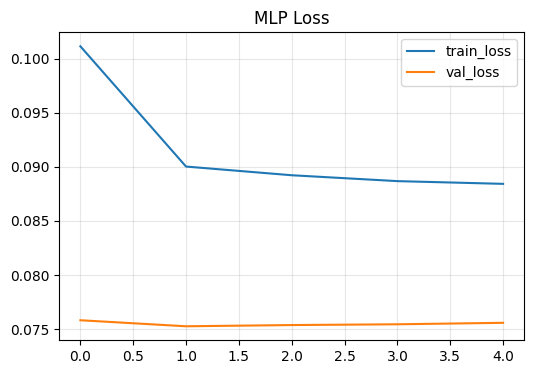

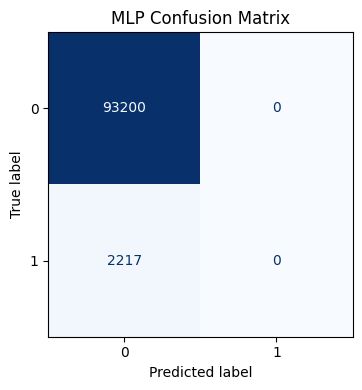

,accuracy,precision,recall,f1_score,roc_auc,confusion_matrix
0,0.9768,0.0,0.0,0.0,0.7562,"[[93200, 0], [2217, 0]]"


In [3]:
# 실행
data = load_data()

print_section('[INFO] MLP 학습 시작')
best_run = None
best_val_auc = -np.inf
run_rows = []

for seed in RUN_SEEDS:
    set_seed(seed)
    model = build_model(data['x_train'].shape[1])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=4,
            restore_best_weights=True,
            verbose=0,
        )
    ]
    history = model.fit(
        data['x_train'],
        data['y_train'],
        validation_data=(data['x_val'], data['y_val']),
        epochs=MLP_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
    )
    val_prob = model.predict(data['x_val'], verbose=0).ravel()
    test_prob = model.predict(data['x_test'], verbose=0).ravel()
    val_auc = roc_auc_score(data['y_val'], val_prob)
    metrics = compute_metrics(data['y_test'], test_prob)
    run_rows.append({'seed': seed, **metrics})
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_run = {
            'seed': seed,
            'model': model,
            'history': history.history,
            'metrics': metrics,
            'y_prob': test_prob,
        }

importance_frame = build_feature_importance(best_run['model'], data)
importance_frame.to_csv(OUTPUT_DIR / 'mlp_feature_importance.csv', index=False)

save_predictions(OUTPUT_DIR / 'mlp_test_predictions.csv', data['test_sample_ids'], data['y_test'], best_run['y_prob'])
save_json(OUTPUT_DIR / 'mlp_metrics.json', {
    'model_name': 'MLP',
    'run_count': len(run_rows),
    'aggregate': {f'{metric}_mean': float(np.mean([row[metric] for row in run_rows])) for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']},
    'best_run': {key: value.tolist() if hasattr(value, 'tolist') else value for key, value in best_run['metrics'].items()} | {'seed': best_run['seed']},
    'prediction_path': 'mlp_test_predictions.csv',
    'history': {key: [float(value) for value in values] for key, values in best_run['history'].items()},
    'feature_importance_path': 'mlp_feature_importance.csv',
})
best_run['model'].save(OUTPUT_DIR / 'mlp_model.keras')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(best_run['history']['loss'], label='train_loss')
ax.plot(best_run['history']['val_loss'], label='val_loss')
ax.set_title('MLP Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(best_run['metrics']['confusion_matrix']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('MLP Confusion Matrix')
plt.tight_layout()
plt.show()

pd.DataFrame([best_run['metrics']]).round(4)
